In [1]:
#Basic libraries
import numpy as np
import pandas as pd

In [2]:
#Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

In [3]:
#!pip install tensorflow==2.7.0
#!pip install pydot

In [4]:
#Evaluation librarry
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [5]:
#Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import sequential
from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.wrappers.scikit_learn import KerasClassifier

In [6]:
#loading digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

In [7]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [8]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [9]:
#let's store the names of the dataset in order in a list
col_names = ['Zero', 'One', 'Two', 'Three', 'Four','Five','Six','Seven','Eight','Nine']           

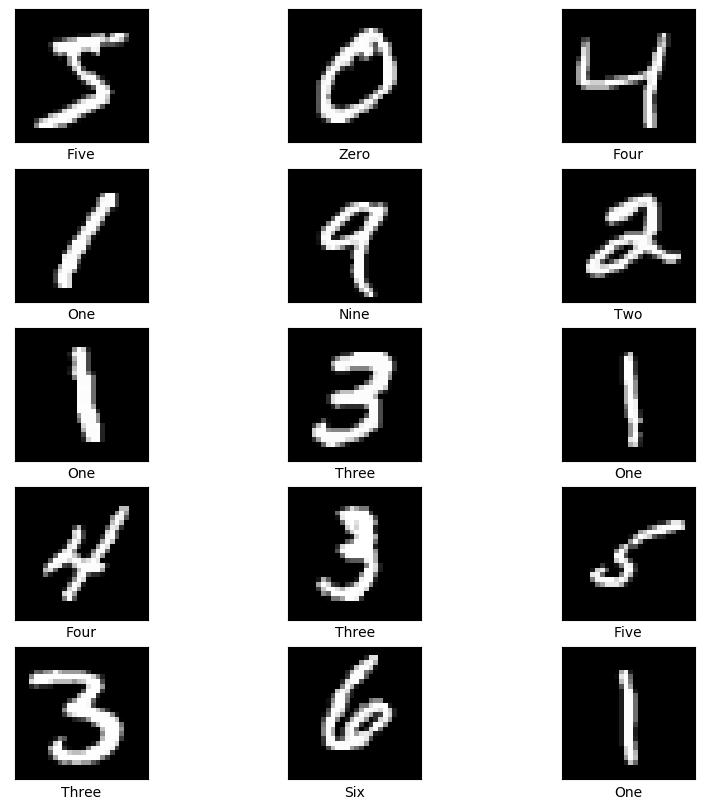

In [10]:
#Visualizing the digits
plt.figure(figsize=(10,10))
for i in range (15):#any numbers that we need to view. Now we say first 15 images in X_train_digit 
    plt.subplot(5,3,i+1) #5,3 is row & colum to display
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]]) # to display respective name under each image
plt.show()

# 0th position in training input and output is 5
# 1st position ...so on

In [11]:
X_train_digit.shape

(60000, 28, 28)

In [12]:
X_test_digit.shape

(10000, 28, 28)

## Preprocessing I/P

In [13]:
#In dataset 60000 is shared in training set and 10000 in test set.each image will have 28X28 matrix array
#ANN model will work only for 2D. So, need to reshape 3D into 2D

In [14]:
#preprocessing inputs
#each cell in each image will be flattened to columns. 28X28=784 columns.
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [15]:
X_train_digit.shape

(60000, 784)

In [16]:
X_test_digit.shape

(10000, 784)

In [17]:
#It is reshaped as 2D now.

## Preprocessing O/P

In [18]:
y_test_digit

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [19]:
y_test_digit.shape

(10000,)

In [20]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [21]:
y_train_digit.shape

(60000,)

In [22]:
#In ANN, If o/p has 1D, it should be converted as classes by one hot encoding

In [23]:
#Encoding Digit MNIST labels
#we will have 0 to 9 (i.e) 10 classes total
y_train_digit = to_categorical(y_train_digit, num_classes=10)
y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [24]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

## Creating base neural network

In [25]:
#ANN & CNN are sequential process. Sequential means one neuron to next neuron or layer
model = keras.Sequential([
#256 is no of connection b/w neurons. Means input to 1st hideen layer. It acts as hypertuning paramenter
#784 is input layer/neuron columns
    layers.Dense(256, activation='relu', input_shape=(784,)),
### !!!When accuracy is low, we can consider below!!!!
### Dropout reduce/drop the number mentioned here (0.3) in accuracy purposefully. It will still push the model to lean well.
### Normalization is like standardization    
    #Layers.Dropout(0.3),
    #Layers.BatchNormalization(),    
#1st hidden layer communicates to 2nd hidden layer with 64 neurons
    layers.Dense(64, activation='relu'),
    #Layers.Dropout(0.3),
    #Layers.BatchNormalization(),
#2nd hidden layer communicates to 3rd hidden layer with 64 neurons
    layers.Dense(64, activation ='relu'),
    #Layers.Dropout(0.3),
    #Layers.BatchNormalization(),
#output layer. #10 is for 10 o/p classes
    layers.Dense(10, activation ='sigmoid'),
])

In [26]:
#param_number = output_channel_number*(input_channel_number +1)
#256*(784+1) = 200960
#64*(256+1) = 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 222,218
Trainable params: 222,218
Non-trainable params: 0
_________________________________________________________________


## Compiling the model


In [27]:
model.compile(loss="categorical_crossentropy",
             optimizer = "adam",
             metrics = ['accuracy'])

## Fit method

In [28]:
history = model.fit(X_train_digit, y_train_digit, batch_size =100, epochs=10, validation_data = (X_test_digit, y_test_digit))
# one epoch means the entire dataset is passed fotward and backword through neural network only once.
# Here 60000 is separated as 100 batch. so epoch will happen for every 600 nuerons for each batch.Thus it will happen 100 times

Epoch 1/10
600/600 [==============================] - 6s 8ms/step - loss: 1.3453 - accuracy: 0.8674 - val_loss: 0.3887 - val_accuracy: 0.9087
Epoch 2/10
600/600 [==============================] - 5s 8ms/step - loss: 0.2535 - accuracy: 0.9369 - val_loss: 0.2569 - val_accuracy: 0.9351
Epoch 3/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1677 - accuracy: 0.9547 - val_loss: 0.2031 - val_accuracy: 0.9501
Epoch 4/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1328 - accuracy: 0.9636 - val_loss: 0.2320 - val_accuracy: 0.9495
Epoch 5/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1172 - accuracy: 0.9672 - val_loss: 0.1597 - val_accuracy: 0.9615
Epoch 6/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1044 - accuracy: 0.9701 - val_loss: 0.1961 - val_accuracy: 0.9580
Epoch 7/10
600/600 [==============================] - 5s 8ms/step - loss: 0.1034 - accuracy: 0.9711 - val_loss: 0.1717 - val_accuracy: 0.9639
Epoch 

## Predict the output for test data

In [29]:
y_predict = model.predict(X_test_digit)

In [30]:
y_predict[0]

array([5.2788615e-02, 9.7358650e-01, 9.3969750e-01, 7.6252472e-01,
       3.3891499e-03, 1.5870497e-01, 1.5105978e-07, 1.0000000e+00,
       7.7483267e-02, 3.7937012e-01], dtype=float32)

In [31]:
#y_predict has 10 output but maximum should be chosen for one pixel.
y_predicts = np.argmax(y_predict, axis=1)# here we get the index if maximum value in the encoded vector

In [32]:
y_predicts

array([7, 2, 1, ..., 3, 5, 6], dtype=int64)

In [33]:
#let's get the maxs for actual test output as well. so we can compare predicted and test output
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [34]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

## confusion matrix for Digit MNIST

In [40]:
con_mat = confusion_matrix(y_test_digit_eval, y_predicts)                      

In [41]:
con_mat

array([[ 971,    0,    0,    0,    1,    2,    2,    1,    3,    0],
       [   0, 1113,    3,    3,    0,    2,    5,    0,    9,    0],
       [  14,    1,  985,   11,    1,    1,    3,    8,    7,    1],
       [   1,    0,    6,  976,    1,    9,    1,    5,    7,    4],
       [  86,    1,   95,  213,  563,    0,    3,    5,    5,   11],
       [   8,    0,    1,  406,   12,  456,    3,    0,    2,    4],
       [  64,    2,    4,    0,   60,  107,  716,    0,    5,    0],
       [   7,    6,   13,    7,   13,    3,    0,  967,    2,   10],
       [  31,    1,   26,   81,    7,  138,    9,    3,  675,    3],
       [   4,    4,    3,   13,  171,    6,    0,    7,   19,  782]],
      dtype=int64)

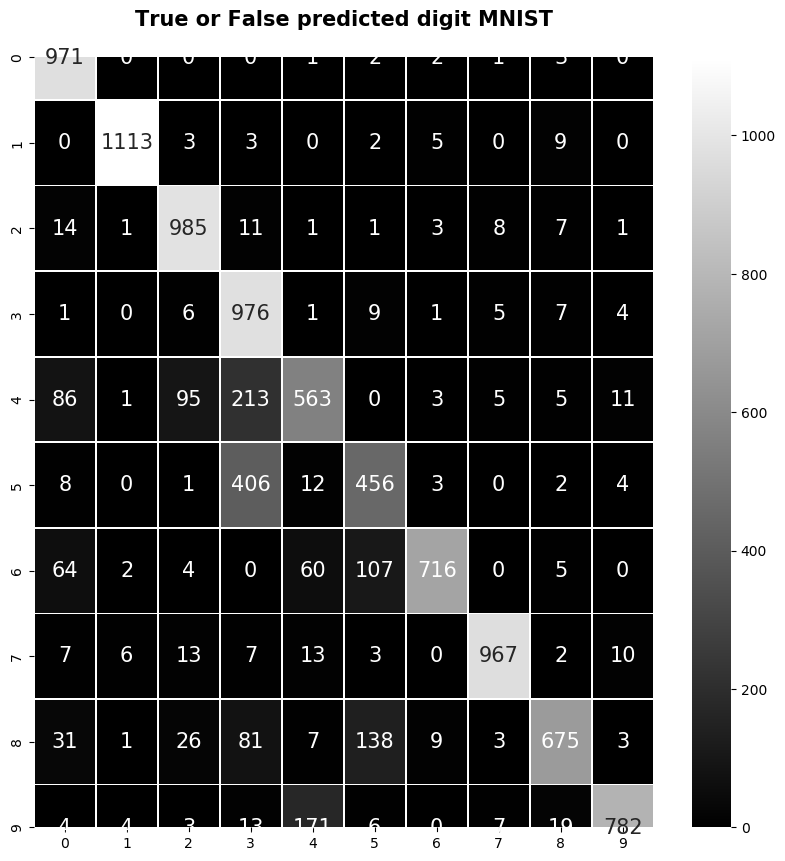

In [42]:
#let's visulaize this in Heatmap
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5, fmt="d", cmap="gray")
plt.title('True or False predicted digit MNIST\n',fontweight = 'bold', fontsize=15)
plt.show()

In [43]:
#let's create classification report.
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90       980
           1       0.99      0.98      0.98      1135
           2       0.87      0.95      0.91      1032
           3       0.57      0.97      0.72      1010
           4       0.68      0.57      0.62       982
           5       0.63      0.51      0.56       892
           6       0.96      0.75      0.84       958
           7       0.97      0.94      0.96      1028
           8       0.92      0.69      0.79       974
           9       0.96      0.78      0.86      1009

    accuracy                           0.82     10000
   macro avg       0.84      0.81      0.81     10000
weighted avg       0.84      0.82      0.82     10000



In [45]:
#overall accuracy is 0.82

In [46]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


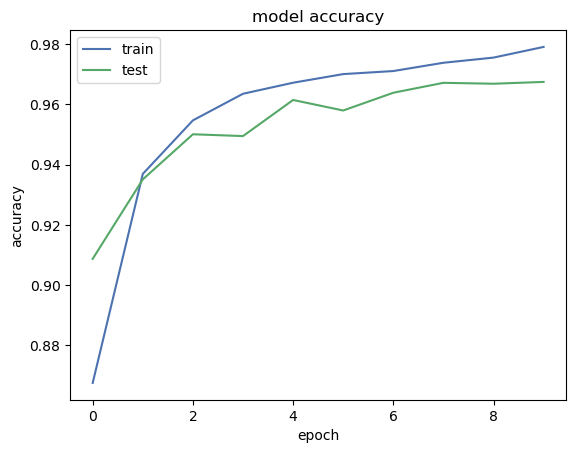

In [47]:
#Summarize the history for accuracy. Historty is just the variable where we stored the model using fit method

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [ ]:
#accuracy goes up from low value always.

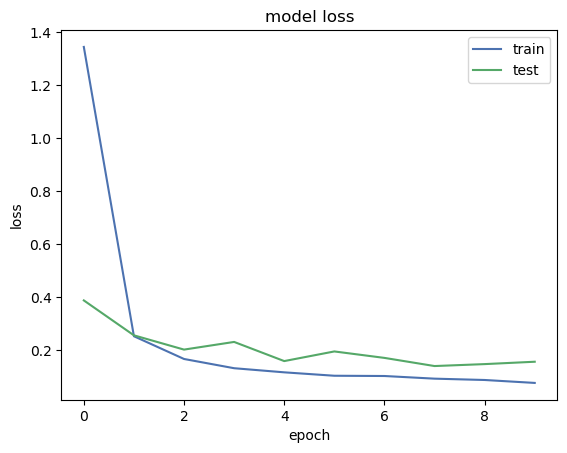

In [50]:
#Summarize the history for loss.

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [51]:
#Loss comes down from high value always.

## Deployment check

In [52]:
#Let's check first for single value from input dataset.
y_predict_single = model.predict(X_test_digit[[2]])
y_predict_single 

array([[9.9787263e-05, 1.0000000e+00, 3.8738906e-02, 5.2741170e-04,
        6.6553396e-01, 1.6505608e-07, 2.5975538e-05, 6.0757834e-01,
        2.9422709e-01, 2.6626968e-01]], dtype=float32)

In [54]:
#pick the max value from predicted values
y_predicts_single = np.argmax(y_predict_single, axis=1)
#do the same for test output
y_test_digit_eval = np.argmax(y_test_digit,axis=1)

## The actual deployment check

<function matplotlib.pyplot.show(*args, **kw)>

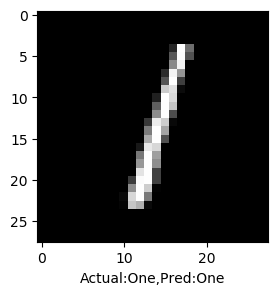

In [71]:
#Names of numbers in the dataset in order
col_names = ['Zero', 'One', 'Two', 'Three', 'Four','Five','Six','Seven','Eight','Nine']

plt.figure(figsize=(3,3))
#We already preprocessed/flattened the inputs. Now we have to reshape it back again to 28X28.
#Giving the input from the 2nd position (i.e) X_test_digit[2]
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')

plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))

#col_names[np.argmax(y_test_digit[2])] -- this holds the respective o/p for given input
#col_names[y_predicts_single[0]] -- here we will have only one number. we did argmax in previous step aleady

plt.show